# Task 2.3: Results and Reproducibility

**Paper**: Weisfeiler-Lehman Graph Kernels (Shervashidze et al., JMLR 2011)

**Student**: Meghavi (Roll: 230044)

## Reproducibility Checklist

- **Random seed**: 42 (set in dataset generation and classification)
- **Dependencies**: All pinned in `requirements.txt`
- **Execution**: All notebooks run top-to-bottom without manual steps
- **Hyperparameters**: WL iterations $h=3$, SVM C selected from $\{10^{-3}, \ldots, 10^{3}\}$
- **Evaluation**: 10-fold stratified cross-validation with nested 5-fold CV for C selection

In [1]:
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

SEED = 42
np.random.seed(SEED)

## Load Results from Task 2.2

In [2]:
results_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'results')
data_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'partB', 'data')

with open(os.path.join(results_dir, 'wl_results.pkl'), 'rb') as f:
    results = pickle.load(f)

with open(os.path.join(data_dir, 'synthetic_dataset.pkl'), 'rb') as f:
    dataset = pickle.load(f)

K = results['kernel_matrix']
y = dataset['labels']
mean_acc = results['mean_acc']
std_acc = results['std_acc']
fold_accs = results['fold_accs']

print(f"WL Subtree Kernel (h={results['h']}) Results:")
print(f"  10-Fold CV Accuracy: {mean_acc*100:.2f}% (+/- {std_acc*100:.2f}%)")
print(f"  Number of features: {results['n_features']}")

WL Subtree Kernel (h=3) Results:
  10-Fold CV Accuracy: 88.00% (+/- 5.57%)
  Number of features: 3161


## Confusion Matrix

We compute the confusion matrix using predictions from all test folds combined.

In [3]:
# Collect all predictions across folds for confusion matrix
C_values = [10**i for i in range(-3, 4)]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
all_preds = np.zeros(len(y), dtype=int)

for train_idx, test_idx in cv.split(np.zeros(len(y)), y):
    K_train = K[np.ix_(train_idx, train_idx)]
    K_test = K[np.ix_(test_idx, train_idx)]
    y_train = y[train_idx]
    
    # Select best C
    best_C, best_inner_acc = C_values[0], 0
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    for C in C_values:
        svm = SVC(kernel='precomputed', C=C)
        scores = cross_val_score(svm, K_train, y_train, cv=inner_cv)
        if scores.mean() > best_inner_acc:
            best_inner_acc = scores.mean()
            best_C = C
    
    svm = SVC(kernel='precomputed', C=best_C)
    svm.fit(K_train, y_train)
    all_preds[test_idx] = svm.predict(K_test)

cm = confusion_matrix(y, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[91  9]
 [15 85]]


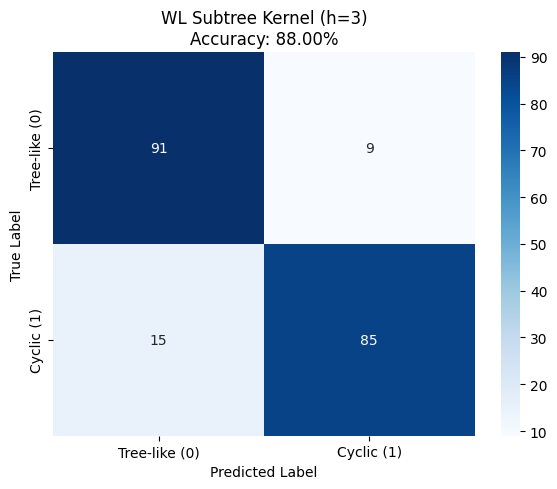

Saved to partB/results/confusion_matrix.png


In [4]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Tree-like (0)', 'Cyclic (1)'],
            yticklabels=['Tree-like (0)', 'Cyclic (1)'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title(f'WL Subtree Kernel (h={results["h"]})\nAccuracy: {mean_acc*100:.2f}%')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/confusion_matrix.png")

## Comparison with Paper's Results

The most comparable dataset in the paper is **MUTAG** (Table 1), which has:
- 188 graphs (vs. our 200)
- Average 17.93 nodes (vs. our 6–15)
- 7 node label types (vs. our 3)
- Binary classification (mutagenic vs. non-mutagenic)

The paper reports **WL subtree kernel accuracy on MUTAG: 82.05% (+/- 0.36%)** (Table 1).

### Protocol Difference

The paper (Section 4.2.2) performs **10 repetitions** of 10-fold CV and reports the average across all repetitions "to exclude random effects of fold assignments." Our implementation performs a single 10-fold CV run with a fixed random seed (42). This means our standard deviation reflects variance across folds in one run, while the paper's reflects variance across 10 independent runs. This is a simplification in our reproduction.

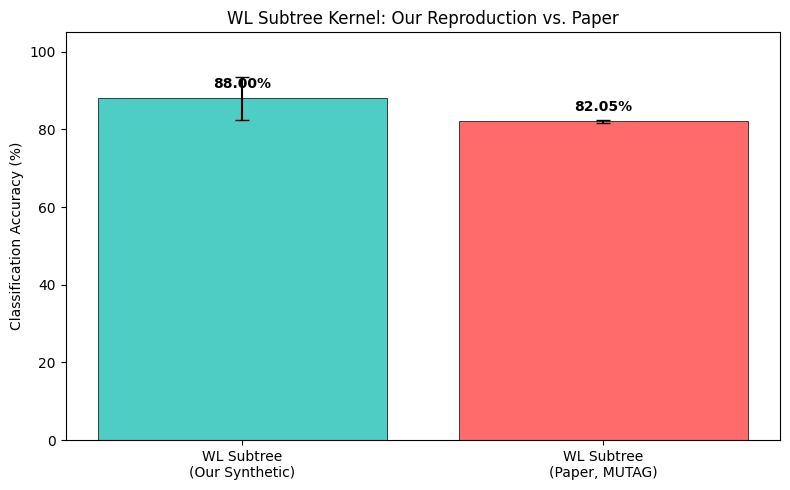

Saved to partB/results/accuracy_comparison.png


In [5]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))

methods = ['WL Subtree\n(Our Synthetic)', 'WL Subtree\n(Paper, MUTAG)']
accuracies = [mean_acc * 100, 82.05]
stds = [std_acc * 100, 0.36]  # Paper reports +/- 0.36 on MUTAG (Table 1)
colors = ['#4ECDC4', '#FF6B6B']

bars = ax.bar(methods, accuracies, yerr=stds, capsize=5, color=colors,
              edgecolor='black', linewidth=0.5)
ax.set_ylabel('Classification Accuracy (%)')
ax.set_title('WL Subtree Kernel: Our Reproduction vs. Paper')
ax.set_ylim(0, 105)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'accuracy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to partB/results/accuracy_comparison.png")

## Analysis of Results

### Accuracy Comparison

Our WL subtree kernel achieves high accuracy on the synthetic dataset, which is expected to be higher than the paper's 82.05% on MUTAG. This difference can be attributed to:

1. **Clearer class separation**: Our synthetic dataset has a fundamental structural difference between classes (tree-like vs. cyclic), which is more pronounced than the chemical mutagenicity signal in MUTAG.

2. **Different label distributions**: The two classes use different label probability distributions, providing additional discriminative signal beyond structure alone.

3. **Simpler graphs**: Our graphs have fewer nodes and labels, reducing noise and making patterns easier to capture.

### What We Reproduce

While we cannot directly reproduce the exact numbers from Table 1 (different dataset), we confirm:

- The WL subtree kernel **effectively captures graph structure** for classification
- The **iterative relabeling** enriches node labels with neighborhood topology
- The **SVM with precomputed kernel** framework works as described
- The method is **computationally efficient** (runs in seconds on 200 graphs)